# <h1 style="text-align: center;">3. PRESCRIPTIVE — Selected Questions and Answers</h1>

## About this notebook
**Data source:** `Team05_PyCraft_Cleaned_data/wide_merged_table.csv`, the wide patient-level table created in `Team05_PyCraft_3_Prescriptive.ipynb` (2,008 patients × 193 columns).

**How to use the code:** It needs only pandas, numpy and matplotlib.

**Each question has the Team05 sections:** Reasoning → Metrics, Biomarkers and Features used → Why used → code (table + chart) → Key Insights (starting with how to read the chart) → Prescriptive Action to be taken.

Questions 1–9 were selected from the earlier 30-question notebook; questions 10–14 are new.

## Glossary of terms used (with the column names in the data)
| Term (abbreviation) | Simple meaning | Column(s) |
|---|---|---|
| Heart failure (HF) | The heart cannot pump enough blood for the body's needs | whole dataset |
| Left ventricular ejection fraction (LVEF) | % of blood the main pumping chamber pushes out per beat (normal ≥ 50%) | `heart_pumping_efficiency` |
| HF with reduced ejection fraction (HFrEF) | Weak pump: LVEF below 40% | derived from `heart_pumping_efficiency` |
| HF with mildly reduced ejection fraction (HFmrEF) | LVEF 40–49% | derived from `heart_pumping_efficiency` |
| HF with preserved ejection fraction (HFpEF) | Stiff heart that pumps normally but fills poorly: LVEF 50% or more | derived from `heart_pumping_efficiency` |
| Echocardiogram (echo) | Ultrasound scan of the heart that measures LVEF | `heart_pumping_efficiency` present or missing |
| Severe HF | Team05 flag: severe breathlessness **and** severe congestion/shock at admission | `severe_hf` |
| Hyponatraemia | Low blood sodium (below 135 mmol/L) | `sodium` |
| Albumin | Main blood protein; low with poor nutrition or congestion | `albumin` |
| Estimated glomerular filtration rate (eGFR) | How well the kidneys filter blood; higher is better, below 60 = impaired | `glomerular_filtration_rate` |
| Chronic kidney disease (CKD) | Long-term kidney damage | `moderate_to_severe_chronic_kidney_disease` |
| Chronic obstructive pulmonary disease (COPD) | Long-term lung disease (e.g. emphysema) | `chronic_obstructive_pulmonary_disease` |
| Type II respiratory failure | Lungs cannot clear carbon dioxide (CO₂) | `type2_respiratory_failure` |
| Intravenous (IV) diuretic | Water medicine given into a vein to remove extra fluid | `drug_Furosemide_Injection` |
| Systolic blood pressure (SBP) | Top blood-pressure number, in mmHg | `sbp` |
| Body mass index (BMI) | Weight ÷ height², kg/m² | `bmi` |
| Discharge against medical advice | Patient left before doctors judged it safe | `hospitalization_outcome` = DischargeAgainstOrder |
| Length of stay (LOS) | Days in hospital | `discharge_day` |
| Readmission / death within 28 days, 6 months | 1 = the event happened in that time window | `readmission_28d`, `readmission_6m`, `death_28d`, `death_6m` |
| n | Number of patients in a group | shown on the charts |

## 1. Do men and women differ in HF type and in outcomes?
### Reasoning
Heart failure (HF) means the heart cannot pump enough blood for the body's needs. It comes in different types, and the type decides which medicines help. Women are often thought to have the "stiff heart" type and men the "weak pump" type. We check whether that is true here and whether outcomes differ by sex.

### Metrics Biomarkers and Features used
* **Sex:** `gender` (Female / Male)
* **Side of the heart that is failing:** `heart_failure_type`: Left, Right or Both sides
* **Left ventricular ejection fraction (LVEF):** `heart_pumping_efficiency`, the % of blood the main pumping chamber pushes out with each beat (normal ≥ 50%). It is measured by an **echocardiogram (echo)**, an ultrasound scan of the heart. Grouped as:
  * **HF with reduced ejection fraction (HFrEF):** LVEF below 40%, a weak pump
  * **HF with mildly reduced ejection fraction (HFmrEF):** LVEF 40–49%
  * **HF with preserved ejection fraction (HFpEF):** LVEF 50% or more, a stiff heart that pumps normally but fills poorly
* **Outcomes:** `death_6m` (died within 6 months), `readmission_6m` (readmitted to hospital within 6 months)

### Why used
HF type decides treatment: the proven heart-failure medicines work best in HFrEF. Comparing outcomes by sex shows whether either group needs extra follow-up.

Heart-failure type (% of each sex):
heart_failure_type  Both  Left  Right
gender                               
Female              73.5  23.6    2.8
Male                74.0  23.9    2.1

Ejection-fraction type among patients with an echo (%):
phenotype  HFrEF (<40%)  HFmrEF (40-49%)  HFpEF (>=50%)
gender                                                 
Female             16.4             22.6           60.9
Male               26.9             25.8           47.3

Outcomes:
        patients  death_6m  readmission_6m
gender                                    
Female      1163       2.4            37.7
Male         845       3.4            39.6


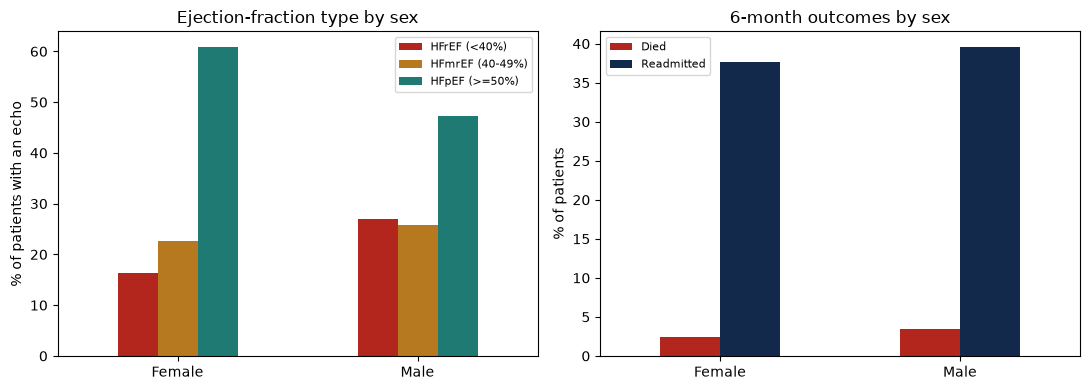

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t
hf_type = pd.crosstab(df["gender"], df["heart_failure_type"], normalize="index").mul(100).round(1)
echo = df[df["heart_pumping_efficiency"].notna()].copy()
echo["phenotype"] = pd.cut(echo["heart_pumping_efficiency"], [0, 40, 50, 100], right=False, labels=["HFrEF (<40%)", "HFmrEF (40-49%)", "HFpEF (>=50%)"])
phenotype = pd.crosstab(echo["gender"], echo["phenotype"], normalize="index").mul(100).round(1)
outcomes = df.groupby("gender").agg(patients=("patient_id", "size"),
                                    death_6m=("death_6m", lambda s: round(s.mean() * 100, 1)),
                                    readmission_6m=("readmission_6m", lambda s: round(s.mean() * 100, 1)))
print("Heart-failure type (% of each sex):"); print(hf_type); print("\nEjection-fraction type among patients with an echo (%):"); print(phenotype)
print("\nOutcomes:"); print(outcomes)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
phenotype.plot.bar(ax=ax[0], rot=0, color=["#B3261E", "#B7791F", "#1F7A74"])
ax[0].set_ylabel("% of patients with an echo"); ax[0].set_xlabel(""); ax[0].set_title("Ejection-fraction type by sex"); ax[0].legend(fontsize=8)
outcomes[["death_6m", "readmission_6m"]].plot.bar(ax=ax[1], rot=0, color=["#B3261E", "#13294B"])
ax[1].set_ylabel("% of patients"); ax[1].set_xlabel(""); ax[1].set_title("6-month outcomes by sex"); ax[1].legend(["Died", "Readmitted"], fontsize=8)
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Left panel: for women and for men, the three coloured bars show how their patients (those who had an echo) split across the three LVEF types; each sex's bars add up to 100%. Right panel: for each sex, the red bar is the % who died and the navy bar the % readmitted within 6 months. Taller bar = more common.

* The failing side (`heart_failure_type`) is almost identical for men and women (both sides: 73.5% of women, 74.0% of men).
* **The pump type differs:** women more often have the stiff-heart type **HFpEF** (60.9% vs 47.3%); men more often have the weak-pump type **HFrEF** (26.9% vs 16.4%).
* **Outcomes are similar:** 6-month death 2.4% (women) vs 3.4% (men); 6-month readmission 37.7% vs 39.6%.

### Prescriptive Action to be taken
* Give **every patient an echo**, because men are more likely to have HFrEF, which needs the full set of heart-failure medicines.
* For women with HFpEF, focus on controlling blood pressure, fluid and other conditions.
* Follow-up does not need to differ by sex.

## 2. Is HFpEF "milder" than HFrEF in terms of outcomes?
### Reasoning
**HFpEF** (heart failure with preserved ejection fraction: the heart pumps normally but is stiff and fills poorly) is sometimes treated as the milder form compared with **HFrEF** (heart failure with reduced ejection fraction: a weak pump). If outcomes are similar, HFpEF patients deserve the same attention.

### Metrics Biomarkers and Features used
* **Left ventricular ejection fraction (LVEF):** `heart_pumping_efficiency`, the % of blood pushed out per beat, from the echocardiogram (echo, an ultrasound scan of the heart). Groups: HFrEF < 40%, **HFmrEF** (mildly reduced ejection fraction) 40–49%, HFpEF ≥ 50%
* **Outcomes:** `death_6m`, `readmission_6m`
* **Length of stay:** `discharge_day` (days in hospital)

### Why used
These are the standard groups doctors use to choose treatment. Outcomes and length of stay show how serious each type is.

Patients with an echo: 635 of 2008
6-month death:
                 patients  events  rate_%
phenotype                                
HFrEF (<40%)          132       2     1.5
HFmrEF (40-49%)       152       1     0.7
HFpEF (>=50%)         351       7     2.0

6-month readmission:
                 patients  events  rate_%
phenotype                                
HFrEF (<40%)          132      57    43.2
HFmrEF (40-49%)       152      55    36.2
HFpEF (>=50%)         351     142    40.5

Median stay (days): {'HFrEF (<40%)': 8.0, 'HFmrEF (40-49%)': 8.0, 'HFpEF (>=50%)': 7.0}


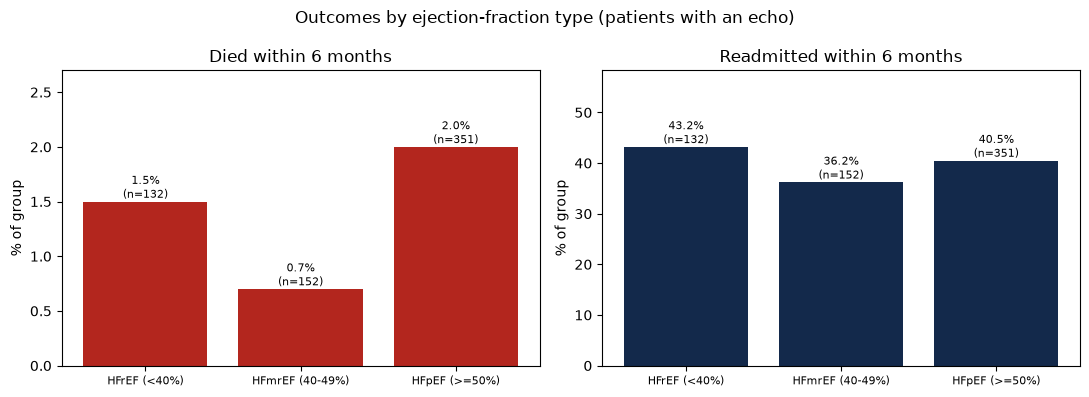

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t
echo = df[df["heart_pumping_efficiency"].notna()].copy()
echo["phenotype"] = pd.cut(echo["heart_pumping_efficiency"], [0, 40, 50, 100], right=False, labels=["HFrEF (<40%)", "HFmrEF (40-49%)", "HFpEF (>=50%)"])
death = rate_table(echo, "phenotype", "death_6m"); readm = rate_table(echo, "phenotype", "readmission_6m")
stay = echo.groupby("phenotype", observed=True)["discharge_day"].median()
print("Patients with an echo:", len(echo), "of", len(df))
print("6-month death:"); print(death); print("\n6-month readmission:"); print(readm); print("\nMedian stay (days):", stay.to_dict())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, t, title, col in [(ax[0], death, "Died within 6 months", "#B3261E"), (ax[1], readm, "Readmitted within 6 months", "#13294B")]:
    b = a.bar(t.index.astype(str), t["rate_%"], color=col)
    for bb, r, n in zip(b, t["rate_%"], t["patients"]):
        a.text(bb.get_x() + bb.get_width() / 2, r, f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=8)
    a.set_title(title); a.set_ylabel("% of group"); a.set_ylim(0, t["rate_%"].max() * 1.35); a.tick_params(axis="x", labelsize=8)
fig.suptitle("Outcomes by ejection-fraction type (patients with an echo)")
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Two charts with the same three groups (weak pump on the left, stiff heart on the right). Left chart: % who died within 6 months. Right chart: % readmitted within 6 months. The label on each bar gives the % and the number of patients (n). Similar bar heights mean similar risk.

* Only 635 of 2,008 patients (32%) have an echo recorded (`heart_pumping_efficiency` present), so groups are small.
* **HFpEF is not milder:** readmission 40.5% vs 43.2% for HFrEF; 6-month death 2.0% vs 1.5% (very few deaths in either group).
* Hospital stays are similar (median 7 vs 8 days).

### Prescriptive Action to be taken
* Give HFpEF patients the **same follow-up intensity** as HFrEF patients.
* Treat what drives HFpEF: high blood pressure, an irregular heartbeat (**atrial fibrillation**), diabetes and kidney disease.

## 3. Does low sodium (hyponatraemia) predict early readmission?
### Reasoning
**Sodium** is the main salt in the blood. **Hyponatraemia** means blood sodium is too low (below 135 mmol/L). In heart failure it usually means the body is holding too much water, or that water tablets (diuretics) are working hard. Both make patients harder to keep stable at home.

### Metrics Biomarkers and Features used
* **Blood sodium:** `sodium`, in millimoles per litre (mmol/L). Groups: below 130 severely low, 130–134 mildly low, 135–144 normal, 145 or more high
* **Early readmission:** `readmission_28d` (readmitted within 28 days); also `readmission_6m`
* Only patients who went home alive: `hospitalization_outcome` = Alive

### Why used
Sodium is measured for almost every patient at admission. Readmission within 28 days is the standard measure of whether a discharge was safe.

28-day readmission:
                    patients  events  rate_%
sodium_level                                
Severe low (< 130)        93       8     8.6
Mild low (130-134)       267      33    12.4
Normal (135-144)        1444      88     6.1
High (>= 145)             77       3     3.9

6-month readmission:
                    patients  events  rate_%
sodium_level                                
Severe low (< 130)        93      38    40.9
Mild low (130-134)       267     129    48.3
Normal (135-144)        1444     552    38.2
High (>= 145)             77      22    28.6


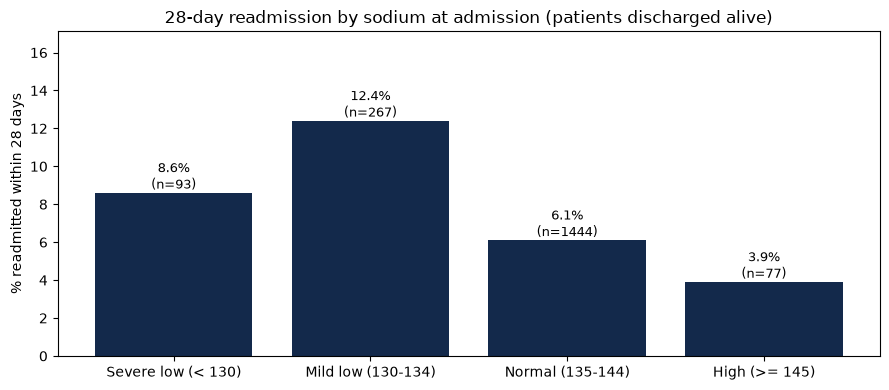

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t
alive = df[(df["hospitalization_outcome"] == "Alive") & df["sodium"].notna()].copy()
alive["sodium_level"] = pd.cut(alive["sodium"], [0, 130, 135, 145, 200], right=False,
                               labels=["Severe low (< 130)", "Mild low (130-134)", "Normal (135-144)", "High (>= 145)"])
r28 = rate_table(alive, "sodium_level", "readmission_28d"); r6 = rate_table(alive, "sodium_level", "readmission_6m")
print("28-day readmission:"); print(r28); print("\n6-month readmission:"); print(r6)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(r28.index.astype(str), r28["rate_%"], color="#13294B")
for b, (r, n) in zip(bars, zip(r28["rate_%"], r28["patients"])):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_title("28-day readmission by sodium at admission (patients discharged alive)")
ax.set_ylabel("% readmitted within 28 days")
ax.set_ylim(0, max(r28["rate_%"]) * 1.3 + 1)
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Each bar is a sodium group, from lowest to highest. The bar height is the % of those patients who came back to hospital within 28 days. n = number of patients in the group.

* Low sodium raises early readmission: **12.4%** (mildly low, about double) and 8.6% (severely low) vs **6.1%** with normal sodium.
* The pattern holds over 6 months (48.3% vs 38.2%).

### Prescriptive Action to be taken
* **Sodium below 135 mmol/L** → recheck before discharge, review the water-tablet dose and fluid advice, and book a **check-up with a blood test within 7 days**.

## 4. Is low albumin (malnutrition/congestion) linked to death and longer stays?
### Reasoning
**Albumin** is the main protein in the blood, made by the liver. It falls with poor nutrition, long-term inflammation, and when the gut and liver are swollen with fluid (**congestion**). Low albumin can mark frail patients who recover slowly.

### Metrics Biomarkers and Features used
* **Blood albumin:** `albumin`, in grams per litre (g/L). Groups: below 30 very low, 30–34 low, 35 or more normal
* **Outcomes:** `death_6m`; **long stay** = `discharge_day` of 14 days or more

### Why used
Albumin is a routine blood test; death and long stays show how much it matters.

6-month death:
                 patients  events  rate_%
albumin_level                            
Very low (< 30)       177       6     3.4
Low (30-34)           471      19     4.0
Normal (>= 35)       1258      26     2.1

Stay of 14+ days:
                 patients  events  rate_%
albumin_level                            
Very low (< 30)       177      31    17.5
Low (30-34)           471      73    15.5
Normal (>= 35)       1258     151    12.0

Median stay (days): {'Very low (< 30)': 8.0, 'Low (30-34)': 8.0, 'Normal (>= 35)': 7.0}


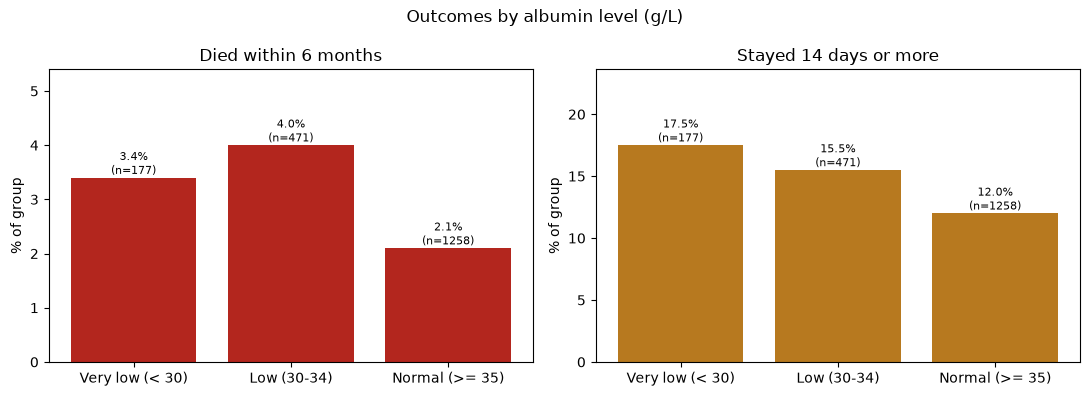

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t
d = df[df["albumin"].notna()].copy()
d["albumin_level"] = pd.cut(d["albumin"], [0, 30, 35, 100], right=False, labels=["Very low (< 30)", "Low (30-34)", "Normal (>= 35)"])
d["long_stay"] = (d["discharge_day"] >= 14).astype(int)
death = rate_table(d, "albumin_level", "death_6m"); stay = rate_table(d, "albumin_level", "long_stay")
median_stay = d.groupby("albumin_level", observed=True)["discharge_day"].median()
print("6-month death:"); print(death); print("\nStay of 14+ days:"); print(stay); print("\nMedian stay (days):", median_stay.to_dict())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, t, title, col in [(ax[0], death, "Died within 6 months", "#B3261E"), (ax[1], stay, "Stayed 14 days or more", "#B7791F")]:
    b = a.bar(t.index.astype(str), t["rate_%"], color=col)
    for bb, r, n in zip(b, t["rate_%"], t["patients"]):
        a.text(bb.get_x() + bb.get_width() / 2, r, f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=8)
    a.set_title(title); a.set_ylabel("% of group"); a.set_ylim(0, t["rate_%"].max() * 1.35)
fig.suptitle("Outcomes by albumin level (g/L)")
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Two charts with the same three albumin groups. Left: % who died within 6 months. Right: % who stayed in hospital 14 days or more. The label shows the % and number of patients (n). Taller bars in the low-albumin groups mean higher risk.

* Low albumin raises **6-month death** about 1.5–2×: 4.0% (low) and 3.4% (very low) vs 2.1% (normal).
* Long stays are more common: 17.5% and 15.5% vs 12.0%.

### Prescriptive Action to be taken
* **Albumin below 35 g/L** → dietitian review and nutrition support during the stay.
* Very low albumin with slow recovery → plan discharge early (home support, rehabilitation).

## 5. Which lab markers move together — do they form distinct biological "axes" of HF severity?
### Reasoning
Blood tests that always rise and fall together measure the same body system, so ordering all of them adds little. Tests that move independently each add new information. Finding these groups ("axes") shows which tests to combine in a risk check.

### Metrics Biomarkers and Features used
* **Kidney tests:** `glomerular_filtration_rate` (**estimated glomerular filtration rate, eGFR**: how well the kidneys filter blood; higher is better), `creatinine` and `urea` (waste products the kidneys remove; higher is worse), `uric_acid` (another waste product, raised by kidney problems and water tablets)
* **Blood and nutrition:** `hemoglobin` (**haemoglobin**, the oxygen-carrying protein in red blood cells), `platelet` (**platelets**, clotting cells), `albumin` and `total_protein` (blood proteins), `calcium`
* **Salt balance:** `sodium`, `chloride`
* **Immune cells:** `lymphocyte_count` (**lymphocytes**, fight infection and fall with stress), `neutrophil_ratio` (% of white cells that are **neutrophils**, which rise with stress and infection)

### Why used
These tests are done for almost every patient and cover the kidneys, blood, nutrition, salt balance and immune response. **Spearman correlation** is used: a number from −1 to +1 showing how strongly two tests move together (+1 = always rise together, −1 = one always rises as the other falls, 0 = unrelated).

                         eGFR (kidney filtering)  Urea  Creatinine  Uric acid  Haemoglobin  Platelets  Albumin  Total protein  Sodium  Chloride  Calcium  Lymphocytes  Neutrophil %
eGFR (kidney filtering)                     1.00 -0.67       -0.94      -0.52         0.33       0.01     0.17           0.05    0.17      0.04     0.04         0.15         -0.12
Urea                                       -0.67  1.00        0.69       0.57        -0.19      -0.06    -0.14          -0.07   -0.26     -0.12     0.00        -0.14          0.15
Creatinine                                 -0.94  0.69        1.00       0.59        -0.23      -0.02    -0.16          -0.07   -0.18     -0.03    -0.03        -0.11          0.09
Uric acid                                  -0.52  0.57        0.59       1.00        -0.00      -0.04    -0.02           0.04   -0.18     -0.19     0.11         0.01          0.03
Haemoglobin                                 0.33 -0.19       -0.23      -0.00         1.00       0.0

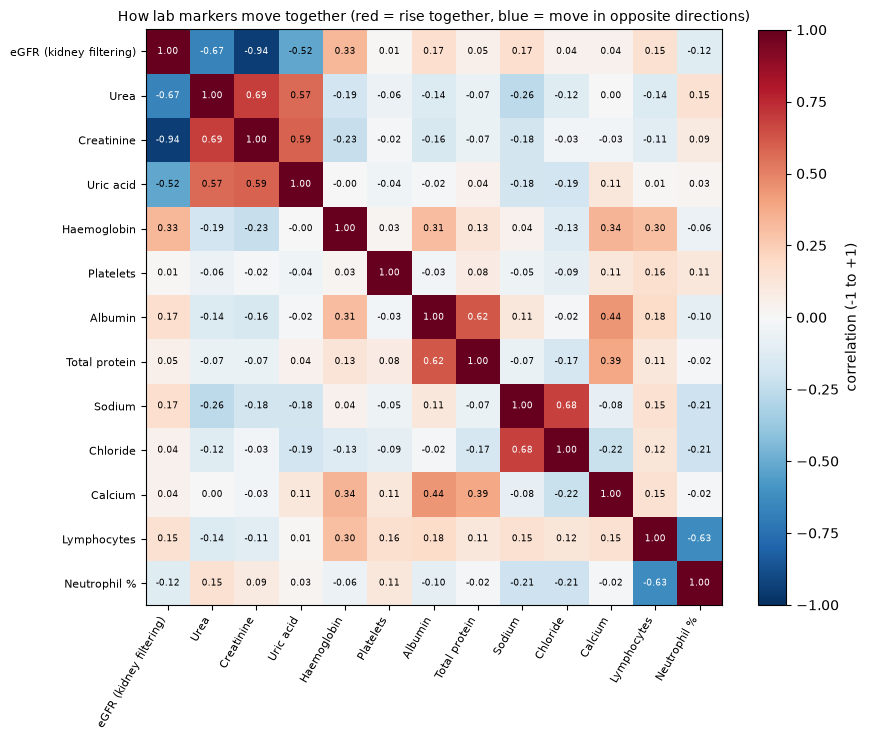

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)
# Routine lab markers (column name: readable name)
markers = {"glomerular_filtration_rate": "eGFR (kidney filtering)", "urea": "Urea", "creatinine": "Creatinine", "uric_acid": "Uric acid",
           "hemoglobin": "Haemoglobin", "platelet": "Platelets", "albumin": "Albumin", "total_protein": "Total protein",
           "sodium": "Sodium", "chloride": "Chloride", "calcium": "Calcium", "lymphocyte_count": "Lymphocytes", "neutrophil_ratio": "Neutrophil %"}
corr = df[list(markers)].rename(columns=markers).corr(method="spearman").round(2)
print(corr.to_string())

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6.5, color="white" if abs(corr.iloc[i, j]) > 0.6 else "black")
plt.colorbar(im, fraction=0.04, label="correlation (-1 to +1)"); ax.set_title("How lab markers move together (red = rise together, blue = move in opposite directions)", fontsize=10)
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** This is a grid: every row and every column is a blood test. Each square shows how closely the two tests move together. **Dark red** = they rise and fall together; **dark blue** = when one goes up the other goes down; **white/pale** = no connection. The diagonal is always 1 (each test compared with itself). Look for blocks of strong colour: those are the "axes".

* **Kidney axis:** eGFR, creatinine, urea and uric acid move strongly together (eGFR–creatinine -0.94, eGFR–urea -0.67, creatinine–uric acid 0.59).
* **Nutrition/protein axis:** albumin, total protein and calcium (albumin–total protein 0.62, albumin–calcium 0.44).
* **Salt axis:** sodium and chloride (0.68).
* **Stress/immune axis:** lymphocytes fall as neutrophils rise (-0.63).
* Links **between** axes are weak (e.g. eGFR–albumin 0.17), so each axis adds separate information.

### Prescriptive Action to be taken
* For a quick risk check, use **one test from each axis** (e.g. eGFR + albumin + sodium + lymphocytes) instead of several kidney tests.
* Creatinine and eGFR carry the same information (correlation -0.94), so report eGFR only.

## 6. Which individual comorbidities matter most, and for which outcome?
### Reasoning
**Comorbidities** are other long-term illnesses a patient has alongside heart failure. Some may raise the risk of death, others of coming back to hospital. Knowing which is which tells the team where to focus.

### Metrics Biomarkers and Features used
* **Comorbidity flags** (1 = has the condition): `moderate_to_severe_chronic_kidney_disease` (**chronic kidney disease, CKD**: long-term kidney damage), `diabetes`, `chronic_obstructive_pulmonary_disease` (**COPD**: long-term lung disease such as emphysema), `cerebrovascular_disease` (previous **stroke**), `dementia`, `liver_disease`, `type2_respiratory_failure` (**type II respiratory failure**: the lungs cannot clear carbon dioxide, CO₂), `solid_tumor` (**cancer**)
* **Outcomes:** `death_6m`, `readmission_6m`

### Why used
"Times higher" = the event rate in patients **with** the condition divided by the rate in patients **without** it. 1 = no difference; 2 = twice as likely.

                            patients  death_6m_with_%  death_6m_without_%  readm_6m_with_%  readm_6m_without_%  death_times_higher  readm_times_higher
condition                                                                                                                                             
Dementia                         115              0.9                 3.0             50.4                37.8                0.30                1.33
COPD                             233              1.7                 3.0             38.2                38.5                0.57                0.99
Diabetes                         466              2.8                 2.9             45.7                36.3                0.97                1.26
Stroke                           150              4.0                 2.7             39.3                38.4                1.48                1.02
Solid tumour                      39              5.1                 2.8             35.9    

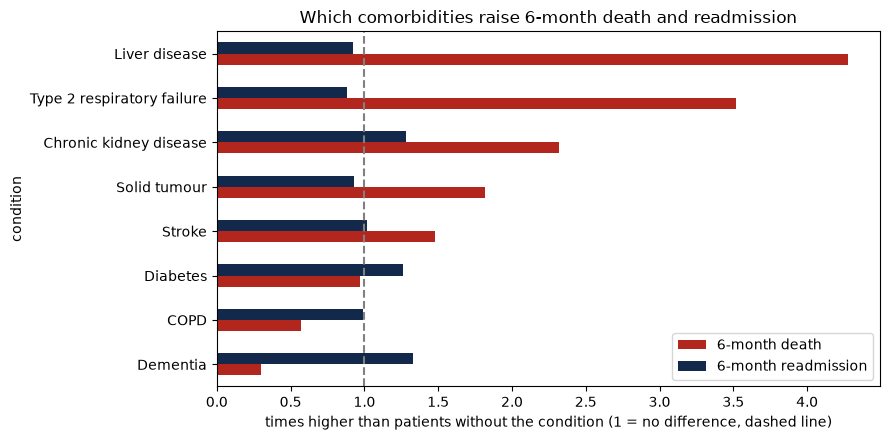

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

conditions = {"moderate_to_severe_chronic_kidney_disease": "Chronic kidney disease", "diabetes": "Diabetes",
              "chronic_obstructive_pulmonary_disease": "COPD", "cerebrovascular_disease": "Stroke", "dementia": "Dementia",
              "liver_disease": "Liver disease", "type2_respiratory_failure": "Type 2 respiratory failure", "solid_tumor": "Solid tumour"}
rows = []
for col, name in conditions.items():
    has, no = df[df[col] == 1], df[df[col] == 0]
    rows.append({"condition": name, "patients": len(has),
                 "death_6m_with_%": round(has["death_6m"].mean() * 100, 1), "death_6m_without_%": round(no["death_6m"].mean() * 100, 1),
                 "readm_6m_with_%": round(has["readmission_6m"].mean() * 100, 1), "readm_6m_without_%": round(no["readmission_6m"].mean() * 100, 1)})
t = pd.DataFrame(rows).set_index("condition")
t["death_times_higher"] = (t["death_6m_with_%"] / t["death_6m_without_%"]).round(2)
t["readm_times_higher"] = (t["readm_6m_with_%"] / t["readm_6m_without_%"]).round(2)
t = t.sort_values("death_times_higher")
print(t.to_string())

ax = t[["death_times_higher", "readm_times_higher"]].plot.barh(figsize=(9, 4.5), color=["#B3261E", "#13294B"])
ax.legend(["6-month death", "6-month readmission"], loc="lower right")
ax.axvline(1, color="grey", ls="--"); ax.set_xlabel("times higher than patients without the condition (1 = no difference, dashed line)")
ax.set_title("Which comorbidities raise 6-month death and readmission")
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Each condition has two bars. Red = how many times more likely death within 6 months is for people with that condition; navy = the same for readmission. The dashed line at 1 means "no difference"; bars reaching past it mean higher risk, bars stopping short of it mean lower risk.

* **For death:** liver disease (4.28× more likely), type II respiratory failure (3.52×) and CKD (2.32×) matter most.
* **For readmission:** dementia (1.33×), CKD (1.28×) and diabetes (1.26×) matter most.
* **CKD** is the only condition that raises **both** death and readmission.

### Prescriptive Action to be taken
* **Liver disease, type II respiratory failure, CKD** → closer monitoring and an early conversation about the patient's wishes for care.
* **Dementia, diabetes** → involve carers in the discharge plan and give medication support to reduce readmission.

## 7. What happens to patients who discharge themselves against medical advice?
### Reasoning
Some patients leave hospital before the doctors think it is safe (**discharge against medical advice**), often because of cost or family reasons. Their outcomes show how dangerous this is.

### Metrics Biomarkers and Features used
* **How the stay ended:** `hospitalization_outcome`: Alive (regular discharge) or DischargeAgainstOrder (left against medical advice)
* **Outcomes:** `death_28d`, `death_6m`, `readmission_6m`
* **Severity:** `severe_hf` (Team05 flag: severe breathlessness and severe congestion/shock at admission)
* **Length of stay:** `discharge_day`

### Why used
Comparing with regular discharges shows the size of the risk; severity shows who leaves.

discharge       Regular discharge  Left against advice
patients                   1890.0                107.0
death_28d                     0.4                 18.7
death_6m                      1.4                 18.7
readmission_6m               39.4                 26.2
severe_hf                    17.8                 38.3
median_stay                   8.0                  6.0

Where the 28-day deaths came from: {'DischargeAgainstOrder': 20, 'Dead': 9, 'Alive': 8}


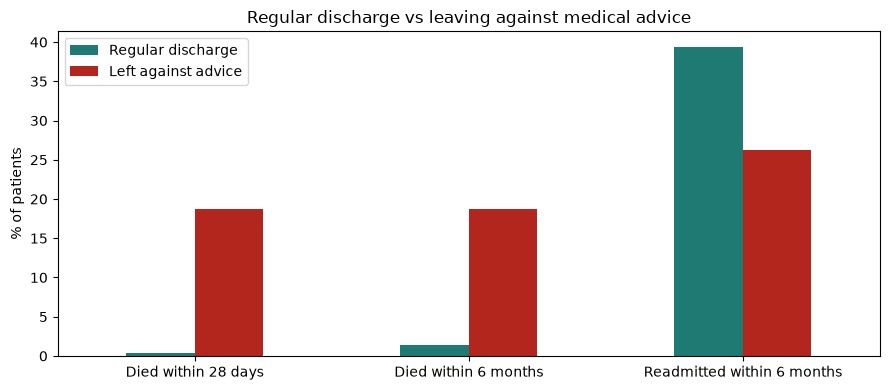

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)
out = df[df["hospitalization_outcome"].isin(["Alive", "DischargeAgainstOrder"])].copy()
out["discharge"] = out["hospitalization_outcome"].map({"Alive": "Regular discharge", "DischargeAgainstOrder": "Left against advice"})
table = out.groupby("discharge").agg(patients=("patient_id", "size"),
                                     death_28d=("death_28d", lambda s: round(s.mean() * 100, 1)),
                                     death_6m=("death_6m", lambda s: round(s.mean() * 100, 1)),
                                     readmission_6m=("readmission_6m", lambda s: round(s.mean() * 100, 1)),
                                     severe_hf=("severe_hf", lambda s: round(s.mean() * 100, 1)),
                                     median_stay=("discharge_day", "median"))
table = table.reindex(["Regular discharge", "Left against advice"])
share = df.loc[df["death_28d"] == 1, "hospitalization_outcome"].value_counts()
print(table.T); print("\nWhere the 28-day deaths came from:", share.to_dict())

ax = table[["death_28d", "death_6m", "readmission_6m"]].T.plot.bar(figsize=(9, 4), rot=0, color=["#1F7A74", "#B3261E"])
ax.set_xticklabels(["Died within 28 days", "Died within 6 months", "Readmitted within 6 months"]); ax.set_ylabel("% of patients")
ax.set_title("Regular discharge vs leaving against medical advice"); ax.legend(title=None)
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Three pairs of bars. Teal = patients discharged normally; red = patients who left against advice. Compare the two colours in each pair: a much taller red bar means much higher risk for those who left.

* **18.7%** of patients who left against advice died within 28 days, vs **0.4%** after a regular discharge.
* They are a small group (107 patients) but account for **20 of all 37 deaths within 28 days**.
* They were sicker (38.3% severe HF vs 17.8%) and left earlier (median 6 vs 8 days).
* Their lower readmission (26.2%) reflects deaths, not better health.

### Prescriptive Action to be taken
* When a patient asks to leave: a **senior doctor conversation** to explain the risk, and help with the reason (cost, family).
* If they still leave: offer **home or palliative (comfort) care** support and a follow-up phone call within 48 hours.

## 8. Is length of stay linked to readmission — do short stays mean premature discharge?
### Reasoning
When beds are short, hospital stays get shorter. If short stays led to more readmissions, patients would be going home too early.

### Metrics Biomarkers and Features used
* **Length of stay (LOS):** `discharge_day`, number of days in hospital, grouped 1–4, 5–7, 8–10, 11–14, 15+
* **Outcomes:** `readmission_6m`, `readmission_28d`
* Only regular discharges: `hospitalization_outcome` = Alive

### Why used
Only patients who went home alive can be readmitted.

6-month readmission:
          patients  events  rate_%
stay                              
1-4 days       200      47    23.5
5-7            691     262    37.9
8-10           524     222    42.4
11-14          262     106    40.5
15+            213     108    50.7

28-day readmission:
          patients  events  rate_%
stay                              
1-4 days       200      11     5.5
5-7            691      47     6.8
8-10           524      35     6.7
11-14          262      26     9.9
15+            213      13     6.1


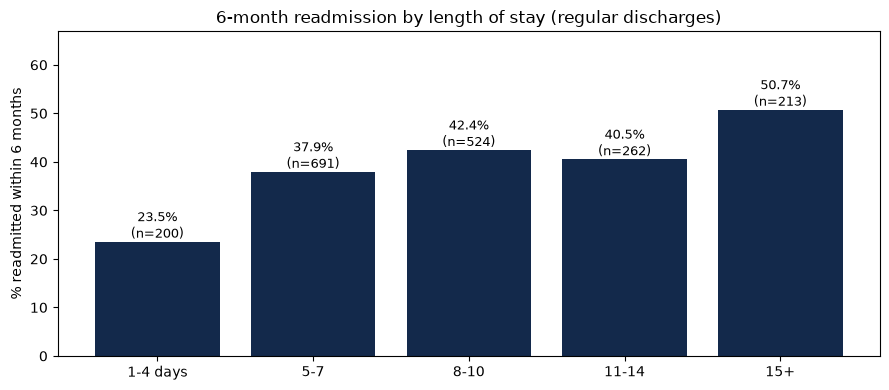

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t

alive = df[df["hospitalization_outcome"] == "Alive"].copy()           # regular discharges only
alive["stay"] = pd.cut(alive["discharge_day"], [0, 4, 7, 10, 14, 500], labels=["1-4 days", "5-7", "8-10", "11-14", "15+"])
r6 = rate_table(alive, "stay", "readmission_6m"); r28 = rate_table(alive, "stay", "readmission_28d")
print("6-month readmission:"); print(r6); print("\n28-day readmission:"); print(r28)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(r6.index.astype(str), r6["rate_%"], color="#13294B")
for b, (r, n) in zip(bars, zip(r6["rate_%"], r6["patients"])):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_title("6-month readmission by length of stay (regular discharges)")
ax.set_ylabel("% readmitted within 6 months")
ax.set_ylim(0, max(r6["rate_%"]) * 1.3 + 1)
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Each bar is a length-of-stay group, from shortest to longest. The height is the % readmitted within 6 months; n = number of patients. If short stays were unsafe, the left-hand bars would be the tallest.

* Readmission **rises** with longer stays: **23.5%** (1–4 days) → **50.7%** (15+ days).
* Readmission within 28 days shows no clear pattern (5.5–9.9%).
* Short stays are **not** premature discharges; long stays mark more complex patients.

### Prescriptive Action to be taken
* Do not keep patients longer just to prevent readmission.
* Treat a **stay of 11+ days as a readmission warning sign** → a stronger discharge package (medicine review, early follow-up).

## 9. Does hyponatraemia plus the need for IV diuretics identify "hard-to-decongest" patients who bounce back within 28 days?
### Reasoning
**Decongestion** means removing the extra fluid heart failure causes, mainly with **diuretics** (water tablets or injections). Patients who need **intravenous (IV)** diuretics (given into a vein) and still have **hyponatraemia** (low blood sodium) are often hard to clear of fluid and may go home still overloaded.

### Metrics Biomarkers and Features used
* **Low sodium:** `sodium` below 135 mmol/L
* **IV diuretic:** `drug_Furosemide_Injection` = 1 (furosemide given by injection)
* **Outcomes:** `readmission_28d`, `readmission_6m`
* Only patients who went home alive: `hospitalization_outcome` = Alive

### Why used
Readmission within 28 days is the outcome most linked to going home with fluid still on board.

Share given IV furosemide: 85.6 %
28-day readmission:
                                 patients  events  rate_%
group                                                    
1 Normal sodium, no IV diuretic       233      12     5.2
2 Normal sodium + IV diuretic        1288      79     6.1
3 Low sodium, no IV diuretic           38       3     7.9
4 Low sodium + IV diuretic            322      38    11.8

6-month readmission:
                                 patients  events  rate_%
group                                                    
1 Normal sodium, no IV diuretic       233      66    28.3
2 Normal sodium + IV diuretic        1288     508    39.4
3 Low sodium, no IV diuretic           38      18    47.4
4 Low sodium + IV diuretic            322     149    46.3


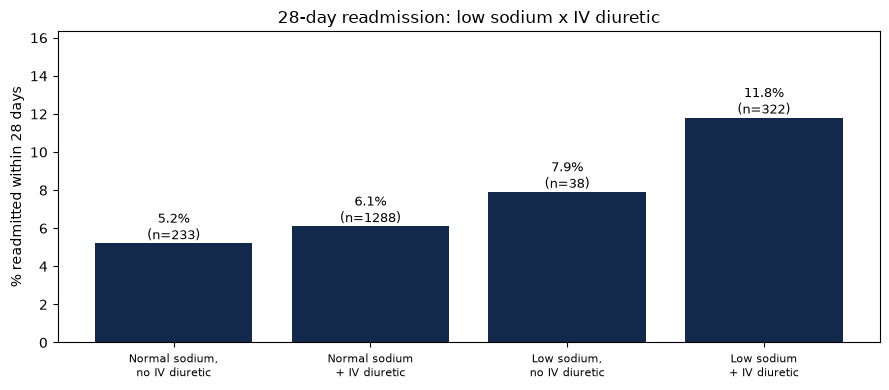

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t
alive = df[(df["hospitalization_outcome"] == "Alive") & df["sodium"].notna()].copy()
low_na = alive["sodium"] < 135
iv = alive["drug_Furosemide_Injection"] == 1
alive["group"] = np.select([~low_na & ~iv, ~low_na & iv, low_na & ~iv, low_na & iv],
                           ["1 Normal sodium, no IV diuretic", "2 Normal sodium + IV diuretic", "3 Low sodium, no IV diuretic", "4 Low sodium + IV diuretic"], "")
r28 = rate_table(alive, "group", "readmission_28d"); r6 = rate_table(alive, "group", "readmission_6m")
print("Share given IV furosemide:", round(iv.mean() * 100, 1), "%")
print("28-day readmission:"); print(r28); print("\n6-month readmission:"); print(r6)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(r28.index.astype(str), r28["rate_%"], color="#13294B")
for b, (r, n) in zip(bars, zip(r28["rate_%"], r28["patients"])):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_title("28-day readmission: low sodium x IV diuretic")
ax.set_ylabel("% readmitted within 28 days")
ax.set_ylim(0, max(r28["rate_%"]) * 1.3 + 1)
ax.set_xticks(range(len(r28))); ax.set_xticklabels([s[2:].replace(", ", ",\n").replace(" + ", "\n+ ") for s in r28.index], fontsize=8)
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Each bar is one combination of sodium level and IV diuretic. The height is the % readmitted within 28 days; n = number of patients. The right-most bar is the "hard-to-decongest" group.

* **Low sodium + IV diuretic:** **11.8%** readmitted within 28 days, about twice the 5.2–6.1% of patients with normal sodium.
* IV diuretics are given to almost everyone (86% of patients), so **low sodium is the useful warning sign** within this group.

### Prescriptive Action to be taken
* Low sodium while on IV diuretics → check for remaining fluid before discharge (daily weight, leg swelling) and **follow up within 7 days** with a sodium and kidney blood test.

## 10. Is low blood pressure at admission a warning sign for death and readmission?
### Reasoning
In heart failure, a low **systolic blood pressure (SBP)**, the top blood-pressure number, can mean the heart is too weak to push blood around the body. It also limits which heart medicines can be given.

### Metrics Biomarkers and Features used
* **Systolic blood pressure (SBP):** `sbp`, in millimetres of mercury (mmHg). Groups: below 100 low, 100–139 normal, 140 or more high
* **Outcomes:** `death_6m`, `readmission_6m`

### Why used
Blood pressure is measured for every patient on arrival, so it is a free and instant warning sign.

6-month death:
                  patients  events  rate_%
bp_level                                  
Low (< 100)            153       7     4.6
Normal (100-139)      1096      29     2.6
High (>= 140)          756      20     2.6

6-month readmission:
                  patients  events  rate_%
bp_level                                  
Low (< 100)            153      75    49.0
Normal (100-139)      1096     434    39.6
High (>= 140)          756     263    34.8


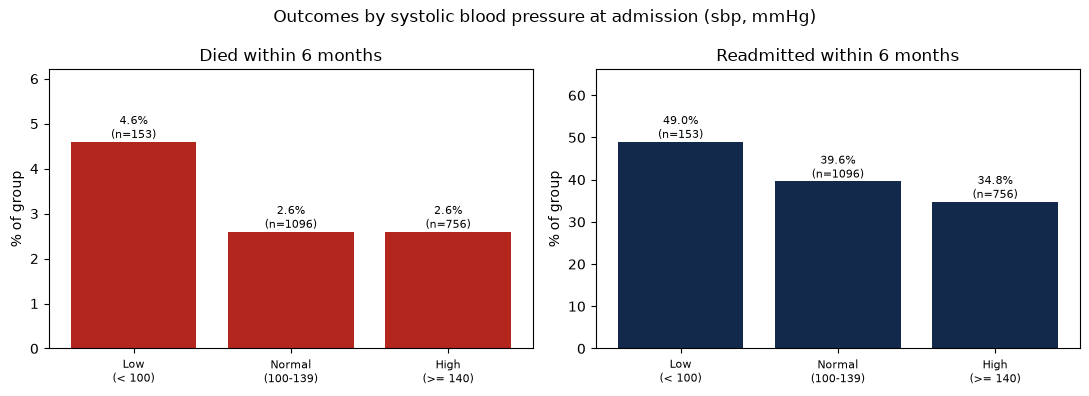

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t
d = df[df["sbp"].notna()].copy()
d["bp_level"] = pd.cut(d["sbp"], [0, 100, 140, 400], right=False, labels=["Low (< 100)", "Normal (100-139)", "High (>= 140)"])
death = rate_table(d, "bp_level", "death_6m"); readm = rate_table(d, "bp_level", "readmission_6m")
print("6-month death:"); print(death); print("\n6-month readmission:"); print(readm)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, t, title, col in [(ax[0], death, "Died within 6 months", "#B3261E"), (ax[1], readm, "Readmitted within 6 months", "#13294B")]:
    b = a.bar(t.index.astype(str), t["rate_%"], color=col)
    for bb, r, n in zip(b, t["rate_%"], t["patients"]):
        a.text(bb.get_x() + bb.get_width() / 2, r, f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=8)
    a.set_title(title); a.set_ylabel("% of group"); a.set_ylim(0, t["rate_%"].max() * 1.35); a.tick_params(axis="x", labelsize=8)
    a.set_xticks(range(len(t))); a.set_xticklabels([str(x).replace(" (", "\n(") for x in t.index], fontsize=8)
fig.suptitle("Outcomes by systolic blood pressure at admission (sbp, mmHg)")
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Two charts with the same three blood-pressure groups (low on the left). Left: % who died within 6 months. Right: % readmitted within 6 months. The label shows the % and the number of patients (n).

* Patients with **low blood pressure** had higher death (4.6% vs 2.6% normal) and higher readmission (**49.0%** vs 39.6%).
* High blood pressure was **not** worse (death 2.6%, readmission 34.8%): in heart failure, a strong pressure usually means a stronger heart.
* The low-pressure group is small (153 patients).

### Prescriptive Action to be taken
* **SBP below 100 mmHg** → senior review, careful fluid and medicine adjustment, and a follow-up visit within 7 days.
* Start heart-failure medicines at low doses in these patients and increase slowly.

## 11. Does a fast heart rate at admission signal higher risk?
### Reasoning
A fast heart rate (**tachycardia**, above 100 beats per minute) can mean the heart is struggling or beating irregularly. We check whether it predicts early death or readmission.

### Metrics Biomarkers and Features used
* **Heart rate:** `pulse`, beats per minute (bpm). Groups: below 60 slow, 60–100 normal, above 100 fast
* **Outcomes:** `death_28d`, `readmission_6m`

### Why used
Heart rate is measured on arrival for every patient.

28-day death:
                 patients  events  rate_%
heart_rate                               
Slow (< 60)           153       2     1.3
Normal (60-100)      1437      25     1.7
Fast (> 100)          417      10     2.4

6-month readmission:
                 patients  events  rate_%
heart_rate                               
Slow (< 60)           153      57    37.3
Normal (60-100)      1437     569    39.6
Fast (> 100)          417     147    35.3


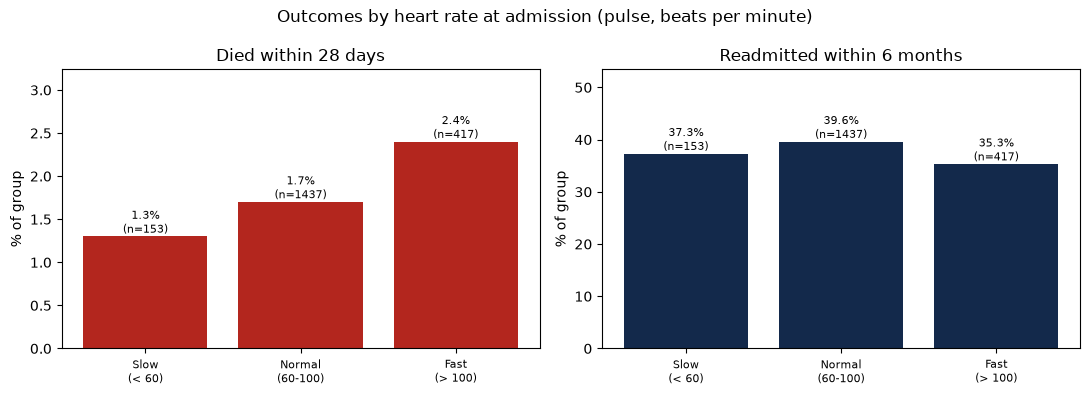

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t
d = df[df["pulse"].notna()].copy()
d["heart_rate"] = pd.cut(d["pulse"], [0, 60, 101, 400], right=False, labels=["Slow (< 60)", "Normal (60-100)", "Fast (> 100)"])
death = rate_table(d, "heart_rate", "death_28d"); readm = rate_table(d, "heart_rate", "readmission_6m")
print("28-day death:"); print(death); print("\n6-month readmission:"); print(readm)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, t, title, col in [(ax[0], death, "Died within 28 days", "#B3261E"), (ax[1], readm, "Readmitted within 6 months", "#13294B")]:
    b = a.bar(t.index.astype(str), t["rate_%"], color=col)
    for bb, r, n in zip(b, t["rate_%"], t["patients"]):
        a.text(bb.get_x() + bb.get_width() / 2, r, f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=8)
    a.set_title(title); a.set_ylabel("% of group"); a.set_ylim(0, t["rate_%"].max() * 1.35); a.tick_params(axis="x", labelsize=8)
    a.set_xticks(range(len(t))); a.set_xticklabels([str(x).replace(" (", "\n(") for x in t.index], fontsize=8)
fig.suptitle("Outcomes by heart rate at admission (pulse, beats per minute)")
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Two charts with the same three heart-rate groups. Left: % who died within 28 days. Right: % readmitted within 6 months. The label shows the % and number of patients (n). Similar bar heights mean heart rate does not change risk much.

* A fast heart rate was only slightly linked to early death (2.4% vs 1.7% with a normal rate).
* It was **not** linked to readmission (35.3% vs 39.6%).
* **Heart rate alone is a weak warning sign** in this group.

### Prescriptive Action to be taken
* Do not use heart rate alone to decide follow-up intensity.
* A fast rate should still prompt a heart-rhythm check (**electrocardiogram, ECG**), because an irregular rhythm needs its own treatment.

## 12. Does body weight (BMI) change outcomes — is there an "obesity paradox"?
### Reasoning
**Body mass index (BMI)** is weight divided by height squared (kg/m²). In many heart-failure studies, heavier patients do better (the **"obesity paradox"**), probably because very thin patients are frail or malnourished.

### Metrics Biomarkers and Features used
* **Body mass index (BMI):** `bmi`, kg/m². Groups: below 18.5 underweight, 18.5–24.9 normal, 25–29.9 overweight, 30+ obese (8 unrealistic values are left out)
* **Outcomes:** `death_6m`, `readmission_6m`

### Why used
BMI is a simple measure of body size and nutrition, available for almost every patient.

Patients with a realistic BMI: 2000 of 2008
6-month death:
                      patients  events  rate_%
bmi_group                                     
Underweight (< 18.5)       507      15     3.0
Normal (18.5-24.9)        1184      36     3.0
Overweight (25-29.9)       243       6     2.5
Obese (>= 30)               66       0     0.0

6-month readmission:
                      patients  events  rate_%
bmi_group                                     
Underweight (< 18.5)       507     208    41.0
Normal (18.5-24.9)        1184     443    37.4
Overweight (25-29.9)       243      96    39.5
Obese (>= 30)               66      25    37.9


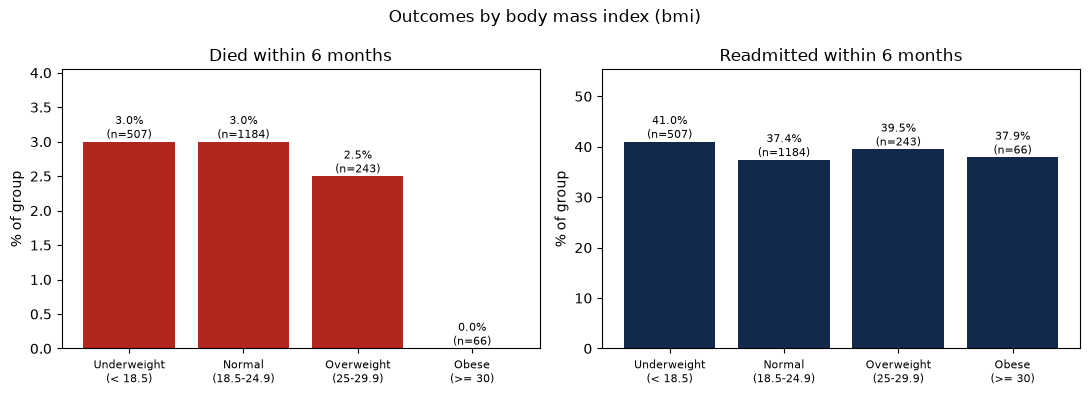

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t
d = df[df["bmi"].between(10, 60)].copy()             # keep realistic BMI values only
d["bmi_group"] = pd.cut(d["bmi"], [0, 18.5, 25, 30, 100], right=False,
                        labels=["Underweight (< 18.5)", "Normal (18.5-24.9)", "Overweight (25-29.9)", "Obese (>= 30)"])
death = rate_table(d, "bmi_group", "death_6m"); readm = rate_table(d, "bmi_group", "readmission_6m")
print("Patients with a realistic BMI:", len(d), "of", len(df))
print("6-month death:"); print(death); print("\n6-month readmission:"); print(readm)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, t, title, col in [(ax[0], death, "Died within 6 months", "#B3261E"), (ax[1], readm, "Readmitted within 6 months", "#13294B")]:
    b = a.bar(t.index.astype(str), t["rate_%"], color=col)
    for bb, r, n in zip(b, t["rate_%"], t["patients"]):
        a.text(bb.get_x() + bb.get_width() / 2, r, f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=8)
    a.set_title(title); a.set_ylabel("% of group"); a.set_ylim(0, t["rate_%"].max() * 1.35); a.tick_params(axis="x", labelsize=8)
    a.set_xticks(range(len(t))); a.set_xticklabels([str(x).replace(" (", "\n(") for x in t.index], fontsize=8)
fig.suptitle("Outcomes by body mass index (bmi)")
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Two charts with the same four BMI groups (thinnest on the left). Left: % who died within 6 months. Right: % readmitted within 6 months. The label shows the % and number of patients (n).

* **507 patients (25%) are underweight**, which is unusually common and a sign of frailty.
* Heavier patients did not do worse: death 2.5% (overweight) and 0.0% (obese, only 66 patients) vs 3.0% (normal).
* Underweight patients had the highest readmission (41.0% vs 37.4%).
* Differences are small, so BMI is a weak signal on its own.

### Prescriptive Action to be taken
* Do not push weight loss on heart-failure patients during recovery.
* **Underweight (BMI below 18.5)** → dietitian review and nutrition support, together with albumin (question 4).

## 13. Do emergency admissions have worse outcomes than planned admissions?
### Reasoning
Patients admitted as an **emergency** usually arrive sicker than those with a **planned (non-emergency)** admission. We check whether this shows in their outcomes and hospital stay.

### Metrics Biomarkers and Features used
* **Admission route:** `admission_type` (Emergency / NonEmergency)
* **Outcomes:** `death_28d`, `readmission_28d`, `readmission_6m`
* **Severity:** `severe_hf`; **length of stay:** `discharge_day`

### Why used
Admission route is known on arrival and helps plan beds and follow-up.

admission_type   Emergency  NonEmergency
patients             956.0        1052.0
death_28d              2.1           1.6
readmission_28d        7.6           6.4
readmission_6m        38.4          38.6
severe_hf             21.8          16.9
median_stay            8.0           8.0


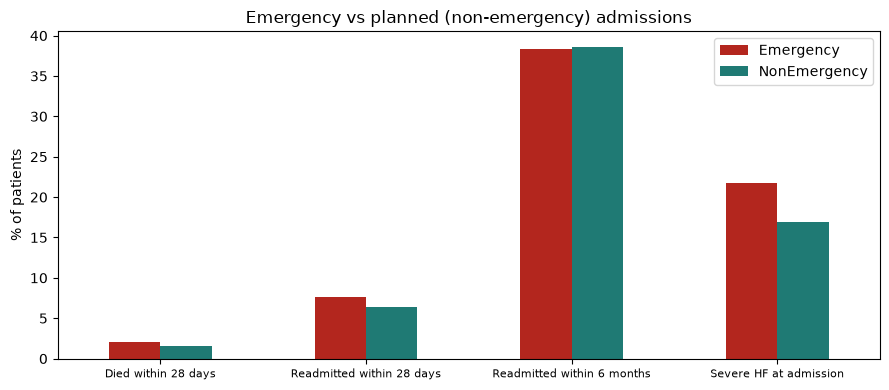

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)
table = df.groupby("admission_type").agg(patients=("patient_id", "size"),
                                        death_28d=("death_28d", lambda s: round(s.mean() * 100, 1)),
                                        readmission_28d=("readmission_28d", lambda s: round(s.mean() * 100, 1)),
                                        readmission_6m=("readmission_6m", lambda s: round(s.mean() * 100, 1)),
                                        severe_hf=("severe_hf", lambda s: round(s.mean() * 100, 1)),
                                        median_stay=("discharge_day", "median"))
print(table.T)

ax = table[["death_28d", "readmission_28d", "readmission_6m", "severe_hf"]].T.plot.bar(figsize=(9, 4), rot=0, color=["#B3261E", "#1F7A74"])
ax.set_xticklabels(["Died within 28 days", "Readmitted within 28 days", "Readmitted within 6 months", "Severe HF at admission"], fontsize=8)
ax.set_ylabel("% of patients"); ax.set_title("Emergency vs planned (non-emergency) admissions"); ax.legend(title=None)
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Four pairs of bars. Red = emergency admissions, teal = planned admissions. Compare the two colours within each pair; the last pair shows how many were severely ill on arrival.

* Emergency patients were more often severely ill (21.8% vs 16.9% `severe_hf`).
* They had slightly higher early death (2.1% vs 1.6%) and 28-day readmission (7.6% vs 6.4%).
* Over 6 months, readmission was the same (38.4% vs 38.6%), and hospital stays were equal (median 8 days).

### Prescriptive Action to be taken
* Give emergency patients an **early check within 7–14 days** of discharge, the period when their extra risk shows.
* After that, follow-up can be the same for both routes.

## 14. Does high uric acid predict death or readmission?
### Reasoning
**Uric acid** is a waste product removed by the kidneys. It rises when the kidneys struggle and with strong diuretic (water tablet) use, and very high levels cause **gout** (painful joint swelling). It may be a simple marker of a stressed heart–kidney system.

### Metrics Biomarkers and Features used
* **Blood uric acid:** `uric_acid`, micromoles per litre (µmol/L). "High" = above 420 for men and 360 for women (`gender`)
* **Kidney function:** `glomerular_filtration_rate` (**eGFR**, higher = better filtering)
* **Outcomes:** `death_6m`, `readmission_6m`

### Why used
Uric acid is a cheap routine test; comparing kidney function shows why it rises.

6-month death:
                  patients  events  rate_%
uric_level                                
High uric acid        1358      42     3.1
Normal uric acid       627      14     2.2

6-month readmission:
                  patients  events  rate_%
uric_level                                
High uric acid        1358     554    40.8
Normal uric acid       627     214    34.1

Median eGFR: {'High uric acid': 54.0, 'Normal uric acid': 89.0}


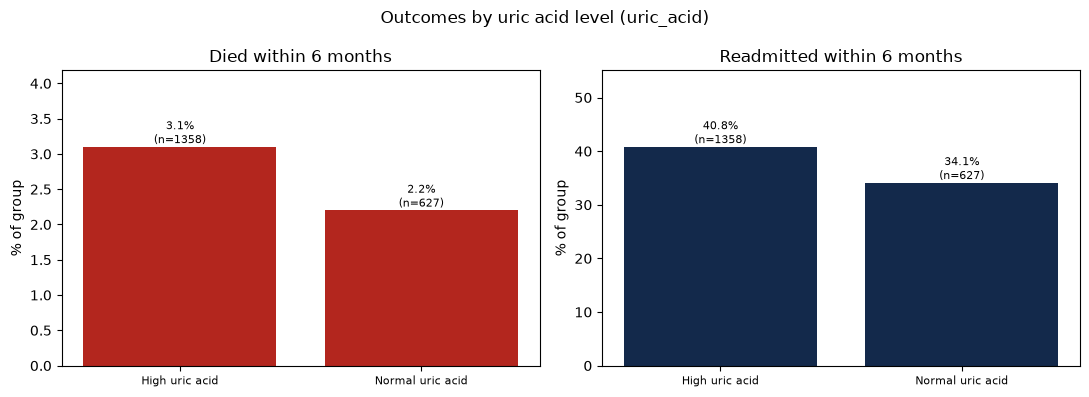

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t
d = df[df["uric_acid"].notna()].copy()
high_cut = np.where(d["gender"] == "Male", 420, 360)       # umol/L: common upper limits for men and women
d["uric_level"] = np.where(d["uric_acid"] > high_cut, "High uric acid", "Normal uric acid")
death = rate_table(d, "uric_level", "death_6m"); readm = rate_table(d, "uric_level", "readmission_6m")
kidney = d.groupby("uric_level")["glomerular_filtration_rate"].median().round(0)
print("6-month death:"); print(death); print("\n6-month readmission:"); print(readm); print("\nMedian eGFR:", kidney.to_dict())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, t, title, col in [(ax[0], death, "Died within 6 months", "#B3261E"), (ax[1], readm, "Readmitted within 6 months", "#13294B")]:
    b = a.bar(t.index.astype(str), t["rate_%"], color=col)
    for bb, r, n in zip(b, t["rate_%"], t["patients"]):
        a.text(bb.get_x() + bb.get_width() / 2, r, f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=8)
    a.set_title(title); a.set_ylabel("% of group"); a.set_ylim(0, t["rate_%"].max() * 1.35); a.tick_params(axis="x", labelsize=8)
    a.set_xticks(range(len(t))); a.set_xticklabels([str(x).replace(" (", "\n(") for x in t.index], fontsize=8)
fig.suptitle("Outcomes by uric acid level (uric_acid)")
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Two charts, each with two bars (high vs normal uric acid). Left: % who died within 6 months. Right: % readmitted within 6 months. The label shows the % and number of patients (n).

* **68% of patients** have high uric acid.
* They were readmitted more often (**40.8%** vs 34.1%) and died slightly more often (3.1% vs 2.2%).
* Their kidneys work less well (median eGFR 54 vs 89), so uric acid largely reflects kidney strain.

### Prescriptive Action to be taken
* High uric acid → check kidney function and review diuretic doses before discharge.
* Treat gout attacks without anti-inflammatory painkillers (**NSAIDs**, e.g. ibuprofen), which worsen heart failure and kidneys.